## Imports

In [1]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
from argparse import Namespace
from sklearn.utils import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.notebook import tqdm
from torchmetrics import Accuracy, F1Score
from sklearn.model_selection import train_test_split
import wandb
from nltk import WordNetLemmatizer
import nltk
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

First we load the dataset that we preprocessed.

In [24]:
df = pd.read_csv('./../data/processed/20newsgroup_preprocessed_own.csv', on_bad_lines='skip', delimiter=";")
print(df.shape)
df.head()

(18828, 3)


,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism resources alt atheism arc...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism introduction alt atheism ...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,article charley wingate writes well john quite...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,kings become philosophers philosophers become ...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,article ida org ida org bob mcgwier writes how...


Next we need to remove rows without a value in the 'text_cleaned' column as that is what we will use.

In [25]:
df = df.dropna(subset=['text_cleaned'])
print(df.shape)

(18792, 3)


## Lemmatization (optional)

In this step we lemmatize all of our words to further preprocess it. For this model lemmatization actually helps so we will use it.

In [26]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = nltk.word_tokenize(text)
    lemmas = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(lemmas)

df['text_cleaned'] = df['text_cleaned'].apply(lambda x: lemmatize_text(x))
df.head()

,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism resource alt atheism arch...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism introduction alt atheism ...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,article charley wingate writes well john quite...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,king become philosopher philosopher become kin...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,article ida org ida org bob mcgwier writes how...


## Stemming (optional)

Stemming has similar results to lemmatization, but it produces slightly worse results. So it wasn't used in the final model. Setemming and lemmatization should not be used together.

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_text(text):
    tokens = nltk.word_tokenize(text)
    stems = [stemmer.stem(token) for token in tokens]
    return ' '.join(stems)

df['text_cleaned'] = df['text_cleaned'].apply(lambda x: stem_text(x))
df.head()

## Encode target labels

This step might not be necessary for all models, but it is good to encode the target labels into numbers instead of using strings.

In [27]:
# Create and fit the encoder on the original target column
label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['target'])

# Print to verify
print("Unique labels in df (encoded):", np.unique(df['target']))
print("Label classes:", label_encoder.classes_)
df.head()

Unique labels in df (encoded): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Label classes: ['alt.atheism' 'comp.graphics' 'comp.os.ms-windows.misc'
 'comp.sys.ibm.pc.hardware' 'comp.sys.mac.hardware' 'comp.windows.x'
 'misc.forsale' 'rec.autos' 'rec.motorcycles' 'rec.sport.baseball'
 'rec.sport.hockey' 'sci.crypt' 'sci.electronics' 'sci.med' 'sci.space'
 'soc.religion.christian' 'talk.politics.guns' 'talk.politics.mideast'
 'talk.politics.misc' 'talk.religion.misc']


,target,text,text_cleaned
0,0,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism resource alt atheism arch...
1,0,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism introduction alt atheism ...
2,0,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,article charley wingate writes well john quite...
3,0,From: mathew <mathew@mantis.co.uk>\nSubject: R...,king become philosopher philosopher become kin...
4,0,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,article ida org ida org bob mcgwier writes how...


## Split the dataset

Before any further modifications we need to split the dataset into train and test subsets so that test values would remain unchanged. it is also important to split the dataset ina way that the training and test sets have the same label distribution.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(df['text_cleaned'], df['target'], test_size=0.2, stratify=df['target'], random_state=42)

## Check distribution of labels

Next we check with a barplot if the distributions are indeed the same between subsets.

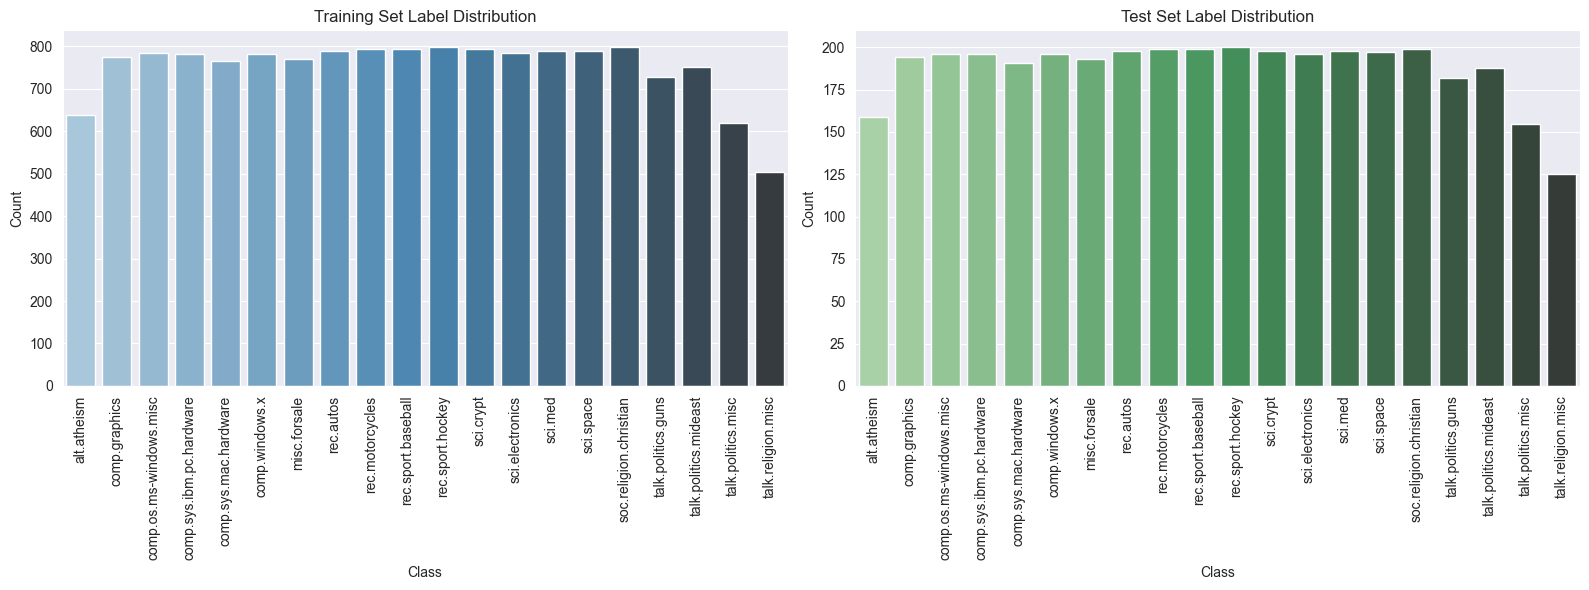

In [29]:
def plot_label_distribution(y_train, y_test, class_names):
    train_counts = pd.Series(y_train).value_counts().sort_index()
    test_counts = pd.Series(y_test).value_counts().sort_index()

    train_df = pd.DataFrame({'Class': class_names, 'Count': train_counts.values})
    test_df = pd.DataFrame({'Class': class_names, 'Count': test_counts.values})

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(data=train_df, x='Class', y='Count', hue='Class', palette="Blues_d", legend=False, ax=axs[0])
    axs[0].set_title('Training Set Label Distribution')
    axs[0].set_ylabel('Count')
    axs[0].set_xlabel('Class')
    axs[0].tick_params(axis='x', rotation=90)

    sns.barplot(data=test_df, x='Class', y='Count', hue='Class', palette="Greens_d", legend=False, ax=axs[1])
    axs[1].set_title('Test Set Label Distribution')
    axs[1].set_ylabel('Count')
    axs[1].set_xlabel('Class')
    axs[1].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()

plot_label_distribution(y_train, y_test, class_names=label_encoder.classes_)

## Chunk the documents

As some documents are longer than others we split them. This will give us more examples as the dataset is relatively small, as well as help the vectorizer better generalize the representations.

We use a chunk size of 150 words with an overlap of 25 words.

In [30]:
def chunk_text(text, chunk_size=50, overlap=15):
    words = text.split()
    if len(words) < chunk_size:
        return [' '.join(words)]  # Keep short texts as a single chunk
    return [' '.join(words[i:i+chunk_size])
            for i in range(0, len(words) - chunk_size + 1, chunk_size - overlap)]

# New lists to store chunked data
X_train_chunked = []
y_train_chunked = []

# Apply chunking
for text, label in zip(X_train, y_train):
    chunks = chunk_text(text, chunk_size=150, overlap=25)
    X_train_chunked.extend(chunks)
    y_train_chunked.extend([label] * len(chunks))

print(f"Original X_train size: {len(X_train)}")
print(f"Chunked X_train size: {len(X_train_chunked)}")

Original X_train size: 15033
Chunked X_train size: 19564


## Prepare BERT - DO NOT USE

At some point during the testing we tried using BERT embeddings (sentence BERT), but they weren't useful as we previously removed all semantic meaning when transforming the documents into individual words.

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')  # fast and decent quality
X_bert = model.encode(df['text_cleaned'].tolist(), show_progress_bar=True)
print(X_bert.shape)

## Tokenizing the documents

Next we train a Tf-idf vectorizer to get a representation containing 50000 of the best features in the dataset. Using an ngram range of 1-3 means we can have two or three words that follow each other as a feature giving some semantic value to them.

In [31]:
# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=50000, stop_words="english", ngram_range = (1,3))

# Transform text data into TF-IDF features
X_tfidf = vectorizer.fit_transform(X_train_chunked)

# Show shape of transformed data
print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (19564, 50000)


## Tokenize test data

Next we tokenize the test dataset with the vectorizer trained on the train dataset.

In [32]:
# Vectorize the test data using the same vectorizer
X_test_tfidf = vectorizer.transform(X_test)

## Create dataset and dataloader

Next up we create dataset and dataloader classes to use in training. This allows us to get batched data.

In [33]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_tfidf.toarray(), y_train_chunked)
test_dataset = TextDataset(X_test_tfidf.toarray(), y_test.values)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=8)

## Create a simple shallow NN

This is a simple shallow but wide model which performed the best so this is what was used to train the final model. 

In [34]:
class MultilayerPerceptron(nn.Module):
    def __init__(self, n_in, n_hidden, n_out, dropout_p):
        super().__init__()
        self.n_in = n_in
        self.n_hidden = n_hidden
        self.n_out = n_out
        self.dropout_p = dropout_p
        
        self.main = nn.Sequential(
            # Input layer
            nn.Linear(self.n_in, self.n_hidden),
            nn.BatchNorm1d(self.n_hidden),
            nn.ReLU(),
            nn.Dropout(self.dropout_p),

            # Hidden layer
            nn.Linear(self.n_hidden, self.n_hidden),
            nn.BatchNorm1d(self.n_hidden),
            nn.ReLU(),
            # nn.Dropout(self.dropout_p),

            # Output layer (logits)
            nn.Linear(self.n_hidden, self.n_out) 
        )

    def forward(self, x):
        return self.main(x)

## Create a simple deep NN

This is another architecture we tried, with more layers to capture more complex relations, however it performed poorly compared to the shallow architecture, and it also took more time to train it.

In [ ]:
class MultilayerPerceptronDeep(nn.Module):
    def __init__(self, n_in, n_hidden, n_out, dropout_p):
        super().__init__()
        self.n_in = n_in
        self.n_hidden = n_hidden
        self.n_hidden2 = n_hidden // 2
        self.n_out = n_out
        self.dropout_p = dropout_p

        self.main = nn.Sequential(
            # Input layer
            nn.Linear(self.n_in, self.n_hidden),
            nn.BatchNorm1d(self.n_hidden),
            nn.ReLU(),
            nn.Dropout(self.dropout_p),

            # Hidden layer
            nn.Linear(self.n_hidden, self.n_hidden),
            nn.BatchNorm1d(self.n_hidden),
            nn.ReLU(),
            nn.Dropout(self.dropout_p),

            # Hidden layer
            nn.Linear(self.n_hidden, self.n_hidden2),
            nn.BatchNorm1d(self.n_hidden2),
            nn.ReLU(),
            nn.Dropout(self.dropout_p),

            # Hidden layer
            nn.Linear(self.n_hidden2, self.n_hidden2),
            nn.BatchNorm1d(self.n_hidden2),
            nn.ReLU(),
            # nn.Dropout(self.dropout_p),

            # Output layer (logits)
            nn.Linear(self.n_hidden2, self.n_out)
        )

    def forward(self, x):
        return self.main(x)

## Model training

This is the training function that is used by both the training script and the sweep script.

In [35]:
def train_model(is_local = True, num_classes = 20, n_in = X_tfidf.shape[1], n_hidden = 256, n_out = 20, epochs = 5, batch_size=8, lr = 0.0001, dropout_p = 0.2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print('Using device:', device)
    if torch.cuda.is_available():
        print("GPU Name: ", torch.cuda.get_device_name())

    model = MultilayerPerceptron(n_in, n_hidden, n_out, dropout_p).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train_chunked), y=y_train_chunked)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

    # Create dataloader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Define metrics
    acc_metric = Accuracy(task="multiclass", num_classes=num_classes, average='macro').to(device)
    f1_macro = F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device)
    f1_weighted = F1Score(task="multiclass", num_classes=num_classes, average='weighted').to(device)

    max_eval_acc = 0.0

    # Training loop
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        acc_metric.reset()
        f1_macro.reset()
        f1_weighted.reset()

        for X_batch, y_batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{epochs}"):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()

            # Forward pass
            outputs = model(X_batch)
            preds = torch.softmax(outputs, dim=1)  # probabilities

            # Compute loss
            loss = criterion(outputs, y_batch)

            # Backward + optimizer step
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Compute accuracy and F1 Scores
            pred_labels = torch.argmax(preds, dim=1)
            acc_metric.update(pred_labels.detach(), y_batch)
            f1_macro.update(pred_labels.detach(), y_batch)
            f1_weighted.update(pred_labels.detach(), y_batch)

        loss = running_loss / len(train_loader)
        acc = acc_metric.compute().item()
        f1_macro_score = f1_macro.compute().item()
        f1_weighted_score = f1_weighted.compute().item()
        eval_acc = evaluate_model(model)

        max_eval_acc = max(max_eval_acc, eval_acc)

        if not is_local:
            wandb.log({
                "epoch": epoch + 1,
                "loss": loss,
                "accuracy": acc,
                "f1_macro": f1_macro_score,
                "f1_weighted": f1_weighted_score,
                "eval_acc": eval_acc,
                "max_eval_acc": max_eval_acc
            })

        print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Accuracy: {acc:.4f}, F1 Macro: {f1_macro_score:.4f}, F1 Weighted: {f1_weighted_score:.4f}, Eval Accuracy: {eval_acc:.4f}, Max Eval Accuracy: {max_eval_acc:.4f}")

    return model

## Evaluation

This function is used to evaluate the model after each epoch on the test dataset to see the evaluation accuracy of the model.

In [36]:
def evaluate_model(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = model.to(device)
    model.eval()

    total = 0
    correct = 0
    
    for texts, labels in tqdm(test_loader, desc="Testing"):
        texts = texts.to(device)
        labels = labels.to(device)
    
        outputs = model(texts)  # [B, C]
        preds = torch.argmax(outputs, dim=1)  # [B]
    
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return 100 * correct / total

## Confusion matrix

This function is responsible for plotting the confusion matrix to see which classes get confused by the model.

In [37]:
def plot_confusion_matrix(model, data_loader, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    for texts, labels in tqdm(data_loader, desc="Generating Confusion Matrix"):
        texts = texts.to(device)
        labels = labels.to(device)

        outputs = model(texts)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

## Train and evaluate

In this cell we define a config which is used for training the model. After it is trained the model is evaluated one last time to see the final results.

In [17]:
cfg = Namespace(
    n_in = X_tfidf.shape[1],
    n_hidden = 512,
    n_out = 20,
    epochs = 3,
    batch_size = 8,
    lr = 0.000025,
    dropout = 0.5,
)

model = train_model(n_in=cfg.n_in, n_hidden=cfg.n_hidden, n_out=cfg.n_out, epochs=cfg.epochs, lr=cfg.lr, dropout_p=cfg.dropout)

accuracy = evaluate_model(model)
print(f"Test Accuracy: {accuracy:.2f}%")

Using device: cuda
GPU Name:  NVIDIA GeForce RTX 3060


Training Epoch 1/3:   0%|          | 0/2445 [00:00<?, ?it/s]

Testing:   0%|          | 0/470 [00:00<?, ?it/s]

Epoch 1, Loss: 1.7467, Accuracy: 0.6345, F1 Macro: 0.6371, F1 Weighted: 0.6455, Eval Accuracy: 86.8848, Max Eval Accuracy: 86.8848


Training Epoch 2/3:   0%|          | 0/2445 [00:00<?, ?it/s]

...

Training Epoch 3/3:   0%|          | 0/2445 [00:00<?, ?it/s]

Testing:   0%|          | 0/470 [00:00<?, ?it/s]

Epoch 3, Loss: 0.2523, Accuracy: 0.9608, F1 Macro: 0.9604, F1 Weighted: 0.9623, Eval Accuracy: 89.7047, Max Eval Accuracy: 89.7047


Testing:   0%|          | 0/470 [00:00<?, ?it/s]

Test Accuracy: 89.70%


We got good results with **~89% accuracy**, the exact number depends on the model as we are using dropout which is random. From the F1 scores we can see that our model is not just guessing but has actual predictive value.

Overall this is a 6% performance gain compared to the previous model.

## Print confusion matrix for the model

Next lets plot a confusion matrix to see where the model struggles to differentiate between classes.

Generating Confusion Matrix:   0%|          | 0/470 [00:00<?, ?it/s]

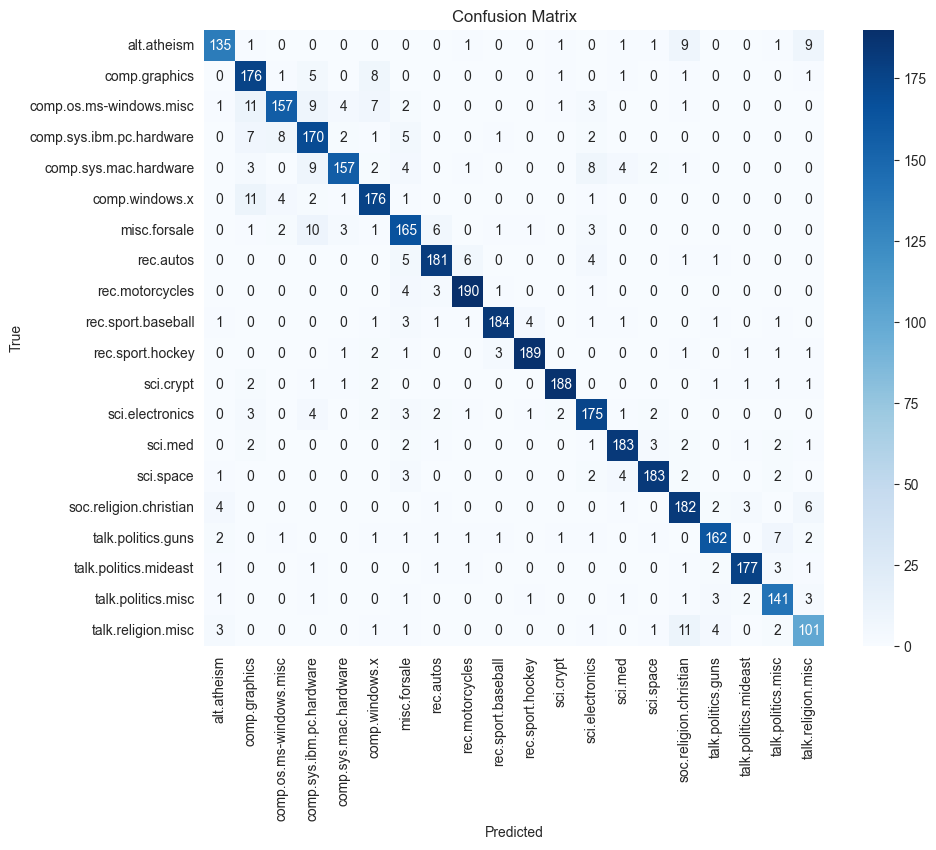

In [38]:
plot_confusion_matrix(model, test_loader, class_names=label_encoder.classes_)

From this matrix we can see that our model still makes mistakes between technology and religion related topics but is much better at distinguishing between them than the previous Naive Bayes model.

## Real word examples

Next lets see how the model performs on real world articles.

## Test on real world data

In [39]:
new_texts = [
    # Windows and PCs
    "This means that any University desktop or laptop PCs which are still using Windows 10 will need to be upgraded to Windows 11 or replaced with more up-to-date equipment if they are unable to support Windows 11, as otherwise they will leave the University exposed to an increased cyber risk. This work is mandatory; any PCs which are still running Windows 10 will be blocked from the University network at some point in the future. Soon, colleagues             and postgraduate researchers with Windows 10 PCs will be able to arrange their own upgrade, and choose a suitable time slot for this.",
    # Rockets and space
    "This week, a busy launch manifest saw SpaceX launch the Crew-10 and two Starlink missions from Florida and the delayed SPHEREx/PUNCH and Transporter 13 missions from California.Outside of the United States, Rocket Lab flew an Electron from New Zealand. A Chang Zhang 8 rocket launched from a new commercial pad in China which also launched two other rockets. A Russian Angara rocket launched an unknown payload from Plesetsk.",
    # Apple Mac Studio
    "Apple today announced the new Mac Studio, the most powerful Mac ever made, featuring M4 Max and the new M3 Ultra chip. The ultimate pro desktop delivers groundbreaking pro performance, extensive connectivity now with Thunderbolt 5, and new capabilities in its compact and quiet design that can live right on a desk. Mac Studio can tackle the most intense workloads with its powerful CPU, Apple’s advanced graphics architecture, higher unified memory capacity, ultrafast SSD storage, and a faster and more efficient Neural Engine. It provides a big boost in performance compared to the previous generation, and a massive leap for users coming from older Macs.",
    # The Pope is dead
    "The seat at the Vatican had been vacant for two days when a group of grey-clad nuns stood on St Peter's Square and started to sing. Softly at first then louder, as if to encourage those who joined in timidly, the nuns broke into Ave Maria. Every so often they shuffled a few inches forward, following the queue for Pope Francis's lying in state. And all the while they sang, their faces turned to St Peter's Basilica to their left, their white veils glistening under their large sun hats. It was a fitting sight for an extraordinary week in which Rome seemed to regain its reputation as the 'capital of the world' – and St Peter's Square as the centre of the Catholic universe.",]

# Lemmatize the articles
lemmatized_new_texts = []
for text in new_texts:
    lemmatized_new_texts.append(lemmatize_text(text))

# Vectorize the articles
new_texts_tfidf = vectorizer.transform(lemmatized_new_texts)  # Transform using the trained vectorizer

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model
model.eval()

inputs = torch.tensor(new_texts_tfidf.toarray(), dtype=torch.float32).to(device)
outputs = model(inputs)
preds = torch.argmax(outputs, dim=1)

print(label_encoder.classes_[preds.cpu().numpy()])

['comp.sys.ibm.pc.hardware' 'sci.space' 'comp.sys.mac.hardware'
 'talk.politics.mideast']


## Experiments

During testing we ran multiple experiments for hyperparameter tuning to see which parameters resulted in the best outputs. All of these experiments were logged using WandB.

In [42]:
wandb.login()

wandb: Currently logged in as: kleeat (dpnerds) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [43]:
# Base sweep config
base_sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "eval_acc",
        "goal": "maximize"
    },
    "parameters": {
        "n_in": {
            "value": X_tfidf.shape[1]
        },
        "n_hidden": {
            "values": [512]
        },"n_out": {
            "value": 20
        },
        "epochs": {
          "values": [3]  
        },
        "batch_size": {
            "value": 8
        },
        "lr": {
            "values": [0.000025]
        },
        "dropout": {
            "values": [0.5]
        }
    }
}

In [44]:
def sweep():
    # Initialize W&B with sweep config
    wandb.init(project="ISA-2-classification")

    config = wandb.config
    n_in = wandb.config.n_in
    n_hidden = config.n_hidden
    n_out = wandb.config.n_out
    epochs = config.epochs
    batch_size = config.batch_size
    lr = config.lr
    dropout = config.dropout
    
    train_model(is_local=False, num_classes=20, n_in=n_in, n_hidden=n_hidden, n_out=n_out, epochs=epochs, batch_size=batch_size, lr=lr, dropout_p=dropout)

### Run sweep

In [45]:
# Set up sweep config
sweep_config = base_sweep_config.copy()
sweep_config["name"] = "Bayes Sweep 8 - Lemmatization - Final"

# Register sweeps
sweep_id = wandb.sweep(sweep_config, project="ISA-2-classification")

# Launch agents
wandb.agent(sweep_id, function=sweep)

Create sweep with ID: a8142o5b
Sweep URL: https://wandb.ai/dpnerds/ISA-2-classification/sweeps/a8142o5b


wandb: Agent Starting Run: b9fk21yb with config:
wandb: 	batch_size: 8
wandb: 	dropout: 0.5
wandb: 	epochs: 3
wandb: 	lr: 2.5e-05
wandb: 	n_hidden: 512
wandb: 	n_in: 50000
wandb: 	n_out: 20


Using device: cuda
GPU Name:  NVIDIA GeForce RTX 3060


Training Epoch 1/3:   0%|          | 0/2445 [00:00<?, ?it/s]

Testing:   0%|          | 0/470 [00:00<?, ?it/s]

...

Training Epoch 3/3:   0%|          | 0/2445 [00:00<?, ?it/s]

Testing:   0%|          | 0/470 [00:00<?, ?it/s]

Epoch 3, Loss: 0.2490, Accuracy: 0.9614, F1 Macro: 0.9609, F1 Weighted: 0.9625, Eval Accuracy: 89.4653, Max Eval Accuracy: 89.4653


accuracy,▁▇█
epoch,▁▅█
eval_acc,▁██
f1_macro,▁▇█
f1_weighted,▁▇█
loss,█▃▁
max_eval_acc,▁██
accuracy,0.96139
epoch,3
eval_acc,89.46528
f1_macro,0.9609


wandb: Ctrl + C detected. Stopping sweep.
